In [1]:
# Imports, as always...
from os import makedirs, path
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import torch

# Data handling.
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# PyTorch models.
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d, Dropout, Softmax, LogSoftmax
from torch.nn import CrossEntropyLoss, BCEWithLogitsLoss, KLDivLoss, MSELoss

# Standard Sklearn classifiers.
from sklearn.svm import SVC

# Graphical imports.
import matplotlib.pyplot as plt
import seaborn as sns

# Script imports.
from scripts.training import train, evaluate
from scripts.data import build_dataframe, build_loaders

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Styling.
palette = 'deep'
sns.set_theme(style='darkgrid', palette=palette)

# Just hard code this.
n = 5

# GPU/CPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# Data.
data_df = pd.read_csv('data/depth-varied/master.csv')
data_df

,n,d,circuit_seed,n_shots,device,task_id,x00000,x00001,x00010,x00011,...,11000,11001,11010,11011,11100,11101,11110,11111,js_div_exp_vs_true,js_div_exp_vs_uni
0,5,5,1,512,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,0.046875,0.066406,0.029297,0.039062,...,0.003836,0.015549,-0.069231,0.006583,-0.052060,0.010440,-0.024609,0.027285,0.379275,0.153007
1,5,5,2,512,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,0.023438,0.021484,0.023438,0.013672,...,0.051527,0.007805,0.008875,0.031173,0.110279,0.046504,0.028302,-0.015205,0.457160,0.185265
2,5,5,3,512,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,0.023438,0.023438,0.003906,0.021484,...,0.016325,-0.003631,-0.075119,-0.024314,-0.007716,0.026292,-0.017913,0.024281,0.322818,0.158453
3,5,5,4,512,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,0.021484,0.009766,0.025391,0.044922,...,-0.007090,-0.112310,0.010305,-0.051118,0.038486,-0.000669,0.036498,-0.004258,0.356680,0.141192
4,5,5,5,512,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,0.029297,0.015625,0.060547,0.025391,...,0.019531,0.033644,0.012881,-0.002283,0.001342,-0.009085,0.041353,-0.004173,0.302920,0.163563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,5,10,696,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.037109,0.009766,0.044922,0.011719,...,-0.017084,-0.011364,0.035137,0.018767,0.004071,-0.014786,-0.016067,0.043513,0.350627,0.224539
5696,5,10,697,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.037109,0.027344,0.054688,0.007812,...,0.066115,-0.044806,0.013450,0.010597,-0.003298,0.023171,0.051696,-0.021079,0.473502,0.242434
5697,5,10,698,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.025391,0.078125,0.039062,0.025391,...,0.008466,-0.023005,-0.030170,-0.032447,-0.001399,0.051817,-0.020291,-0.021988,0.363026,0.249252
5698,5,10,699,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.097656,0.044922,0.007812,0.013672,...,-0.000552,-0.011479,-0.001848,-0.002699,0.006674,0.063290,0.037107,0.003850,0.341550,0.270721


In [3]:
# Sampling a subset of the dataframe, keeping the classes balanced.
# Just two devices for now.
def stratified_sample(df, n, device_a_label=0, device_b_label=1, random_state=None):
    assert n % 2 == 0, 'Even n required.'
    
    # Split into device 0 and device 1.
    df_0 = df[df['device'] == device_a_label]
    df_1 = df[df['device'] == device_b_label]

    # Sample.
    sample_0 = df_0.sample(n=n//2, random_state=random_state)
    sample_1 = df_1.sample(n=n//2, random_state=random_state)
    
    # Combine and shuffle the result
    result = pd.concat([sample_0, sample_1]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return result

In [4]:
# Subset for between devices of the same type:
subset_same = data_df[data_df['device'] != 'Aria-1'].replace({'Ankaa-3':0, 'Garnet':1})
# Subset for between devices of differing type:
subset_diff = data_df[data_df['device'] != 'Garnet'].replace({'Ankaa-3':0, 'Aria-1':1})

## Distinguishing Devices by Discrepancy

Top-level training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 010: train loss - 0.444, val loss - 0.453, train acc - 0.615, val acc - 0.606
Epoch 020: train loss - 0.428, val loss - 0.440, train acc - 0.641, val acc - 0.629
Epoch 030: train loss - 0.414, val loss - 0.436, train acc - 0.659, val acc - 0.627
Epoch 040: train loss - 0.409, val loss - 0.432, train acc - 0.669, val acc - 0.623
Epoch 050: train loss - 0.391, val loss - 0.430, train acc - 0.682, val acc - 0.637
Epoch 060: train loss - 0.384, val loss - 0.431, train acc - 0.700, val acc - 0.623
Epoch 070: train loss - 0.376, val loss - 0.427, train acc - 0.710, val acc - 0.623
Epoch 080: train loss - 0.375, val loss - 0.428, train acc - 0.717, val acc - 0.617
Epoch 090: train loss - 0.370, val loss - 0.432, train acc - 0.714, val acc - 0.640
Epoch 100: train loss - 0.366, val loss - 0.430, train acc - 0.710, val acc - 0.633
Epoch 110: train loss - 0.356, val loss - 0.427, train acc - 0.729, val acc - 0.619
Epoch 120: train loss - 0.357, val loss - 0.431, train acc - 0.730, val acc 

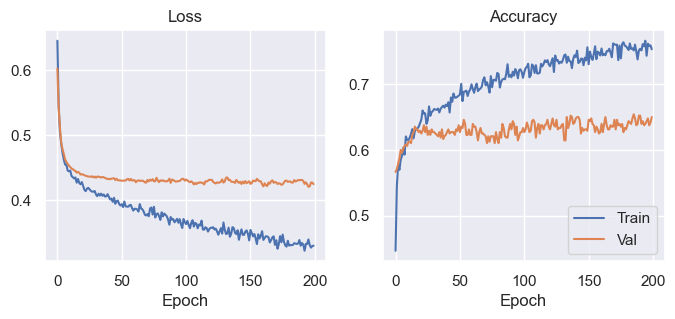

In [21]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    # Distinguishing between the like-devices.
    data_df=subset_same[subset_same['d'] < 25],
    # Features are discrepancies.
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
model = Sequential(
    Linear(2 ** n, 128), BatchNorm1d(128), ReLU(), Dropout(.5),
    Linear(128, 64), BatchNorm1d(64), ReLU(), Dropout(.5),
    Linear(64, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader,
                                                       n_epochs=200, lr=5e-4, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [22]:
evaluate(model, device, test_loader, BCEWithLogitsLoss())

(0.45211011954520175, 0.62375)

In [37]:
subset = subset_same[subset_same['d'] < 25]
X, y = subset[[format(i, f'0{n}b') for i in range(2 ** n)]].to_numpy().astype(np.float32), subset['device'].to_numpy().astype(np.float32)
X_train, _, y_train, _ = train_test_split(
    X, y, test_size=.2, shuffle=True, random_state=0
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=.15, shuffle=True, random_state=0
)

# Alternatively, a simple SVC.
clf = SVC(C=1.5, kernel='rbf', gamma='scale')
clf.fit(X_train, y_train)

correct = 0
for i, (x, y_true) in enumerate(zip(X_val, y_val)):
    y_pred = clf.predict(x.reshape(1, -1))
    correct += int(y_pred == y_true)

correct /= len(y_val)
print(round(correct, 4))

0.6458


### Focusing on specific depths...

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.605, val loss - 0.598, train acc - 0.510, val acc - 0.592
Epoch 020: train loss - 0.518, val loss - 0.536, train acc - 0.613, val acc - 0.625
Epoch 030: train loss - 0.478, val loss - 0.496, train acc - 0.668, val acc - 0.633
Epoch 040: train loss - 0.441, val loss - 0.471, train acc - 0.674, val acc - 0.658
Epoch 050: train loss - 0.421, val loss - 0.453, train acc - 0.696, val acc - 0.650
Epoch 060: train loss - 0.409, val loss - 0.440, train acc - 0.703, val acc - 0.667
Epoch 070: train loss - 0.394, val loss - 0.432, train acc - 0.716, val acc - 0.650
Epoch 080: train loss - 0.397, val loss - 0.425, train acc - 0.709, val acc - 0.658
Epoch 090: train loss - 0.378, val loss - 0.420, train acc - 0.729, val acc - 0.675
Epoch 100: train loss - 0.380, val loss - 0.413, train acc - 0.737, val acc - 0.683
Epoch 110: train loss - 0.341, val loss - 0.408, train acc - 0.754, val acc - 0.683
Epoch 120: train loss - 0.336, val loss - 0.407, train acc - 0.765, val acc 

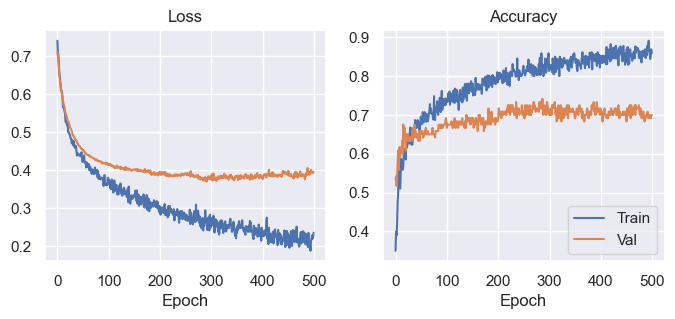

In [38]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    # Like-type, for depth-5 only.
    data_df=subset_same[subset_same['d'] == 5],
    # Discrepancy features.
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader,
                                                       n_epochs=500, lr=1e-4, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [39]:
evaluate(model, device, test_loader, BCEWithLogitsLoss())

(0.3844281210699429, 0.695)

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.553, val loss - 0.547, train acc - 0.632, val acc - 0.792
Epoch 020: train loss - 0.428, val loss - 0.452, train acc - 0.772, val acc - 0.817
Epoch 030: train loss - 0.372, val loss - 0.389, train acc - 0.818, val acc - 0.808
Epoch 040: train loss - 0.335, val loss - 0.353, train acc - 0.812, val acc - 0.817
Epoch 050: train loss - 0.285, val loss - 0.323, train acc - 0.834, val acc - 0.825
Epoch 060: train loss - 0.290, val loss - 0.302, train acc - 0.834, val acc - 0.817
Epoch 070: train loss - 0.257, val loss - 0.284, train acc - 0.834, val acc - 0.825
Epoch 080: train loss - 0.231, val loss - 0.269, train acc - 0.871, val acc - 0.825
Epoch 090: train loss - 0.243, val loss - 0.259, train acc - 0.832, val acc - 0.817
Epoch 100: train loss - 0.231, val loss - 0.253, train acc - 0.857, val acc - 0.817
Epoch 110: train loss - 0.216, val loss - 0.252, train acc - 0.884, val acc - 0.808
Epoch 120: train loss - 0.199, val loss - 0.241, train acc - 0.887, val acc 

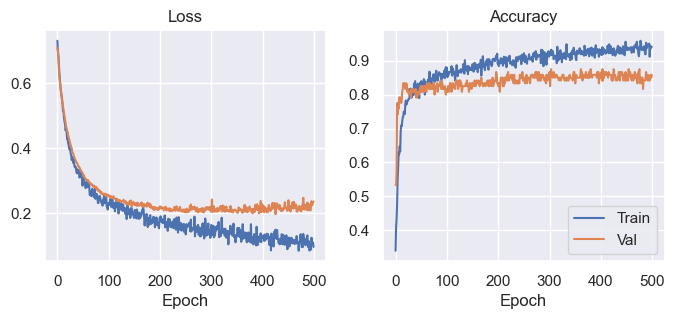

In [40]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    # Like-type, depth-5.
    data_df=subset_same[subset_same['d'] == 5],
    # Raw measurement features.
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader,
                                                       n_epochs=500, lr=1e-4, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [41]:
evaluate(model, device, test_loader, BCEWithLogitsLoss())

(0.20371104538636872, 0.885)

In [42]:
# Lots of depths...
stats = {}
for d in tqdm(subset_same['d'].unique()):
    # Build subset loaders.
    train_loader, val_loader, test_loader = build_loaders(
        subset_same[subset_same['d'] == d],
        feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
        label_cols=['device'],
        split=[.2, .15],
        batch_size=32
    )
    
    # Model.
    hidden_size = 1024
    model = Sequential(
        Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
        Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
        Linear(hidden_size, subset_same['device'].nunique())
    )
    model.to(device)

    stats[d] = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader, n_epochs=300, lr=1e-4, weight_decay=1e-4, verbose=False)

  0%|          | 0/5 [00:00<?, ?it/s]

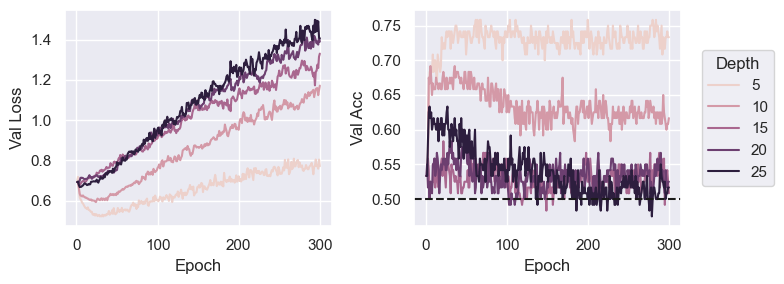

In [43]:
# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

# Val losses.
stats_df = []
for d, (_, _, array_a, array_b) in stats.items():
    for i, (a, b) in enumerate(zip(array_a, array_b)):
        stats_df.append({'Epoch': i+1, 'Depth': d, 'Val Loss': a, 'Val Acc': b})

stats_df = pd.DataFrame(stats_df)

sns.lineplot(stats_df, x='Epoch', y='Val Loss', hue='Depth', ax=ax_loss)
sns.lineplot(stats_df, x='Epoch', y='Val Acc', hue='Depth', ax=ax_acc)
ax_acc.axhline(.5, color='k', linestyle='--')

ax_loss.legend().set_visible(False)
legend = ax_acc.legend(title='Depth', loc='center left', bbox_to_anchor=(1.05, 0.5))

### How much data is needed?

In [16]:
stats = {}
for n_samples in tqdm(np.arange(10, 500, step=10)):
    batch_size = 32
    
    # Build loaders.
    train_loader, val_loader, test_loader = build_loaders(
        data_df=stratified_sample(data_df[data_df['d'] == 5], n=2*n_samples),
        feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
        label_cols=['device'],
        split=[.2, .15],
        batch_size=batch_size
    )
    
    # Model.
    hidden_size = 128
    model = Sequential(
        Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
        Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
        Linear(hidden_size, data_df['device'].nunique())
    )
    model.to(device)
    
    # Train.
    _ = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader, n_epochs=300, lr=1e-4, weight_decay=1e-4, verbose=False)
    
    # Evaluate.
    stats[n_samples] = evaluate(model, device, val_loader, BCEWithLogitsLoss())[1]

  0%|          | 0/49 [00:00<?, ?it/s]

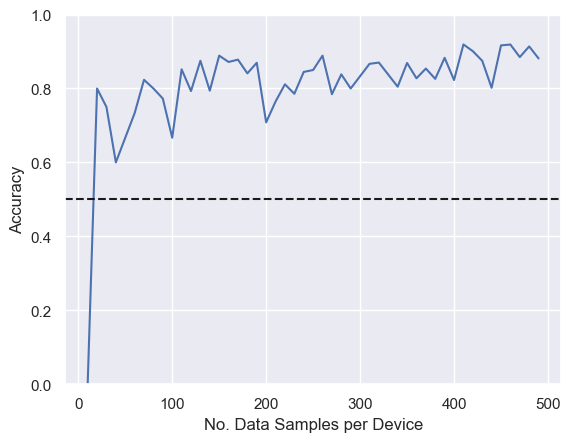

In [18]:
# Plot.
plt.plot(stats.keys(), stats.values())
plt.ylabel('Accuracy')
plt.xlabel('No. Data Samples per Device')
plt.axhline(.5, color='k', linestyle='--')
plt.ylim(0, 1)
plt.show()

## Distinguishing Devices Without True Distribution Knowledge

Top-level training:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 010: train loss - 0.389, val loss - 0.405, train acc - 0.748, val acc - 0.765
Epoch 020: train loss - 0.333, val loss - 0.352, train acc - 0.778, val acc - 0.765
Epoch 030: train loss - 0.325, val loss - 0.337, train acc - 0.783, val acc - 0.758
Epoch 040: train loss - 0.313, val loss - 0.322, train acc - 0.786, val acc - 0.773
Epoch 050: train loss - 0.298, val loss - 0.313, train acc - 0.805, val acc - 0.785
Epoch 060: train loss - 0.288, val loss - 0.317, train acc - 0.802, val acc - 0.767
Epoch 070: train loss - 0.288, val loss - 0.308, train acc - 0.808, val acc - 0.781
Epoch 080: train loss - 0.287, val loss - 0.310, train acc - 0.801, val acc - 0.779
Epoch 090: train loss - 0.281, val loss - 0.301, train acc - 0.817, val acc - 0.792
Epoch 100: train loss - 0.275, val loss - 0.302, train acc - 0.815, val acc - 0.787
Epoch 110: train loss - 0.283, val loss - 0.298, train acc - 0.808, val acc - 0.794
Epoch 120: train loss - 0.259, val loss - 0.301, train acc - 0.824, val acc 

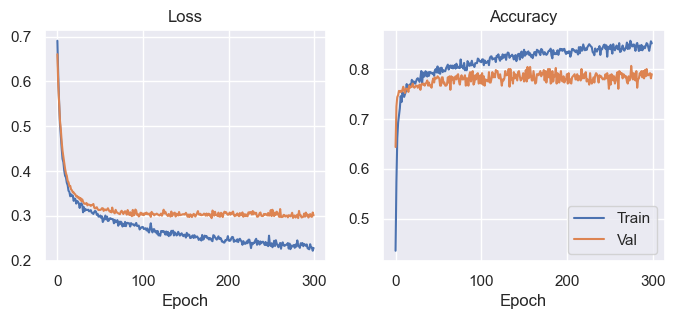

In [44]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    # Like-type.
    data_df=subset_same[subset_same['d'] < 25],
    # Raw only.
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader, val_loader,
                                                       n_epochs=300, lr=1e-4, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [45]:
evaluate(model, device, test_loader, BCEWithLogitsLoss())

(0.2866390740582426, 0.8075)

## Distinguishing Depths by Discrepancy 

In [5]:
# Turn depths into labels.
subset_same['d'] = (subset_same['d'] // 5) - 1
subset_diff['d'] = (subset_diff['d'] // 5) - 1

Top-level training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 010: train loss - 1.513, val loss - 1.527, train acc - 0.317, val acc - 0.273
Epoch 020: train loss - 1.462, val loss - 1.520, train acc - 0.345, val acc - 0.292
Epoch 030: train loss - 1.424, val loss - 1.519, train acc - 0.368, val acc - 0.313
Epoch 040: train loss - 1.408, val loss - 1.522, train acc - 0.379, val acc - 0.298
Epoch 050: train loss - 1.389, val loss - 1.538, train acc - 0.396, val acc - 0.312
Epoch 060: train loss - 1.353, val loss - 1.560, train acc - 0.409, val acc - 0.298
Epoch 070: train loss - 1.366, val loss - 1.553, train acc - 0.403, val acc - 0.290
Epoch 080: train loss - 1.350, val loss - 1.557, train acc - 0.416, val acc - 0.295
Epoch 090: train loss - 1.338, val loss - 1.559, train acc - 0.420, val acc - 0.325
Epoch 100: train loss - 1.329, val loss - 1.571, train acc - 0.435, val acc - 0.302
Epoch 110: train loss - 1.328, val loss - 1.564, train acc - 0.427, val acc - 0.285
Epoch 120: train loss - 1.289, val loss - 1.574, train acc - 0.446, val acc 

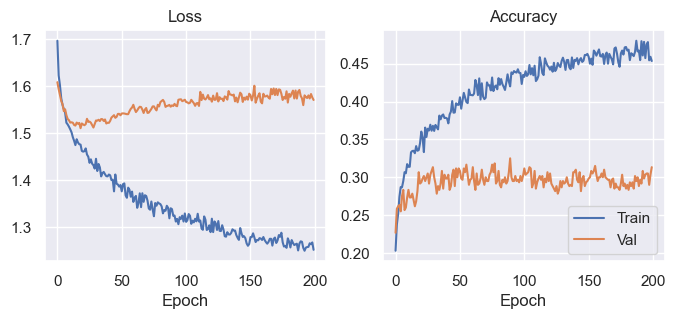

In [6]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    # Like-type.
    data_df=subset_same,
    # Discrepancy.
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['d'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, subset_same['d'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, CrossEntropyLoss(), train_loader, val_loader,
                                                       n_epochs=200, lr=1e-3, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [7]:
evaluate(model, device, test_loader, CrossEntropyLoss())

(1.526060290787882, 0.296)

Top-level training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 010: train loss - 1.311, val loss - 1.307, train acc - 0.362, val acc - 0.385
Epoch 020: train loss - 1.270, val loss - 1.268, train acc - 0.401, val acc - 0.394
Epoch 030: train loss - 1.249, val loss - 1.264, train acc - 0.407, val acc - 0.392
Epoch 040: train loss - 1.225, val loss - 1.261, train acc - 0.431, val acc - 0.373
Epoch 050: train loss - 1.212, val loss - 1.260, train acc - 0.447, val acc - 0.367
Epoch 060: train loss - 1.199, val loss - 1.251, train acc - 0.442, val acc - 0.365
Epoch 070: train loss - 1.183, val loss - 1.237, train acc - 0.450, val acc - 0.377
Epoch 080: train loss - 1.169, val loss - 1.247, train acc - 0.464, val acc - 0.390
Epoch 090: train loss - 1.182, val loss - 1.242, train acc - 0.451, val acc - 0.373
Epoch 100: train loss - 1.176, val loss - 1.231, train acc - 0.450, val acc - 0.396
Epoch 110: train loss - 1.153, val loss - 1.238, train acc - 0.478, val acc - 0.404
Epoch 120: train loss - 1.158, val loss - 1.242, train acc - 0.459, val acc 

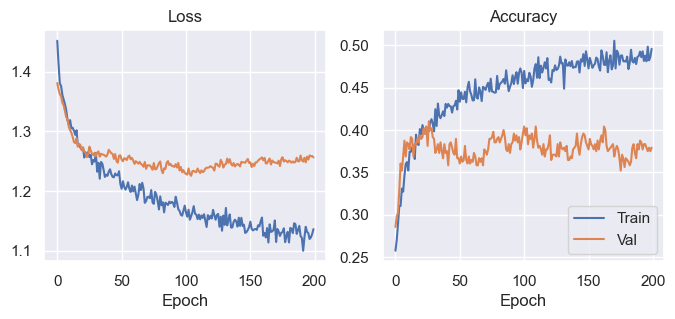

In [9]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    data_df=subset_same[subset_same['d'] < 4],
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['d'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 64
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, subset_same['d'].nunique()-1)
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, CrossEntropyLoss(), train_loader, val_loader,
                                                       n_epochs=200, lr=1e-3, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [10]:
evaluate(model, device, test_loader, CrossEntropyLoss())

(1.3009767527494114, 0.35375)

## Learning to Clean Noise

Given the obtained probability distribution, `x00001, ..., x11111`, can we learn to pick through the noise to return something close to the expected probability distribution, `y00001, ..., y11111`? 

In [11]:
# This needs a tweaked training loop (we're now doing regression, not classification).
from torch.optim import Adam
from torch.nn.functional import one_hot


def training_step_reg(model, device, loader, optimiser, loss_fn):
    # Use train mode.
    model.train()

    # Track the running loss.
    running_loss = 0

    # Iterate over the loader.
    for xs, ys_true in loader:
        # Move to device.
        xs = xs.to(device)
        ys_true = ys_true.to(device)

        # Zero gradients.
        optimiser.zero_grad()

        # Predict.
        ys_pred = model(xs)
        
        # To probabilities (or log-probabilities).
        if type(loss_fn) is KLDivLoss:
            ys_pred = LogSoftmax()(ys_pred)
        else:
            ys_pred = Softmax()(ys_pred)

        # Compute loss (adding to the running loss) and calculate gradients.
        loss = loss_fn(ys_pred, ys_true)
        running_loss += loss.item()
        loss.backward()

        # Adjust weights.
        optimiser.step()

    # Return the average loss and accuracy over the epoch.
    return running_loss / len(loader)


# Function to evaluate with the given loader (i.e. validation/testing).
def evaluate_reg(model, device, loader, loss_fn):
    # Use evaluation mode.
    model.eval()

    # Track the running loss and accuracy.
    running_loss = 0

    # For evaluation, we do not track gradients.
    with torch.no_grad():
        # Iterate over the loader.
        for xs, ys_true in loader:
            # Move to device.
            xs = xs.to(device)
            ys_true = ys_true.to(device)

            # Predict labels.
            ys_pred = model(xs)
            
            # To probabilities (or log-probabilities).
            if type(loss_fn) is KLDivLoss:
                ys_pred = LogSoftmax()(ys_pred)
            else:
                ys_pred = Softmax()(ys_pred)

            # Compute loss (adding to the running loss).
            running_loss += loss_fn(ys_pred,ys_true).item()

    # Return the average loss and accuracy over the loader.
    return running_loss / len(loader)


def train_reg(
        model, device, loss_fn, train_loader, val_loader, 
        n_epochs, lr=1e-3, weight_decay=.0, verbose=False, print_interval=10, 
        save_dir=None, save_file_name='model-dict', seed=0
):
    # RNG.
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Create the save directory.
    if save_dir: makedirs(save_dir, exist_ok=True)

    # Set up an optimiser and loss function.
    optimiser = Adam(params=model.parameters(), lr=lr, weight_decay=weight_decay)

    # Track the best validation loss so that we may return to the best weights on termination.
    best_val_loss = np.inf
    best_state = model.state_dict()

    # Remember the training statistics, just in case someone feels like plotting it.
    train_losses, val_losses  = [], []

    for epoch_idx in (
    tqdm(np.arange(1, n_epochs + 1), desc='Top-level training') if verbose else np.arange(1, n_epochs + 1)):
        # Train the model.
        train_loss = training_step_reg(model, device, train_loader, optimiser, loss_fn)
        val_loss = evaluate_reg(model, device, val_loader, loss_fn)

        # Store those stats.
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Update the best validation loss and remember the model's state.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

            # Save the model (if a save path has been given).
            if save_dir: torch.save(best_state, path.join(save_dir, f'{save_file_name}.pt'))

        # Print the stats (if verbose).
        if verbose and epoch_idx % print_interval == 0:
            print(
                f'Epoch {epoch_idx:03d}: train loss - {train_loss:.3f}, val loss - {val_loss:.3f}')

    # Restore the best model in validation.
    model.load_state_dict(best_state)

    # Return the stats.
    return train_losses, val_losses

Top-level training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 010: train loss - 0.462, val loss - 0.419
Epoch 020: train loss - 0.432, val loss - 0.417
Epoch 030: train loss - 0.419, val loss - 0.417
Epoch 040: train loss - 0.412, val loss - 0.418
Epoch 050: train loss - 0.405, val loss - 0.419
Epoch 060: train loss - 0.401, val loss - 0.420
Epoch 070: train loss - 0.394, val loss - 0.422
Epoch 080: train loss - 0.388, val loss - 0.423
Epoch 090: train loss - 0.383, val loss - 0.426
Epoch 100: train loss - 0.377, val loss - 0.429


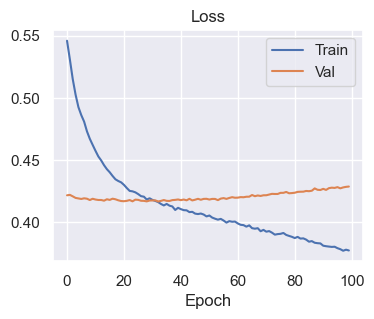

In [14]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    data_df=subset_same[subset_same['d'] < 4],
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['y' + format(i, f'0{n}b') for i in range(2 ** n)],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 1024
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, 2 ** n),
)
model.to(device)

train_losses, val_losses = train_reg(
    model, device, KLDivLoss(reduction='batchmean'), train_loader, val_loader, 
    n_epochs=100, lr=1e-4, weight_decay=1e-4, verbose=True
)

# Set up a figure and axes.
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax, label='Train')
sns.lineplot(x=epochs, y=val_losses, ax=ax, label='Val')

# Beautification.
ax.set_title('Loss')
ax.set_xlabel('Epoch')

plt.show()

In [15]:
for X, Y_true in val_loader:
    X = X.to(device)
    Y_true = Y_true.to(device)
    Y_pred = Softmax()(model(Y_true))
    
    print('X')
    print(X.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_pred')
    print(Y_pred.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_true')
    print(Y_true.detach().cpu().numpy()[0][:5], '...')
    print()
    print('|Y_pred - Y_true|')
    print(abs((Y_pred - Y_true).detach().cpu().numpy())[0][:5], '...')
    
    break

X
[0.03515625 0.0234375  0.03320312 0.01953125 0.0234375 ] ...

Y_pred
[0.01775599 0.01645295 0.01658097 0.03167538 0.01640636] ...

Y_true
[0.03830994 0.07491215 0.00583394 0.03038802 0.02883894] ...

|Y_pred - Y_true|
[0.02055394 0.05845919 0.01074702 0.00128736 0.01243258] ...


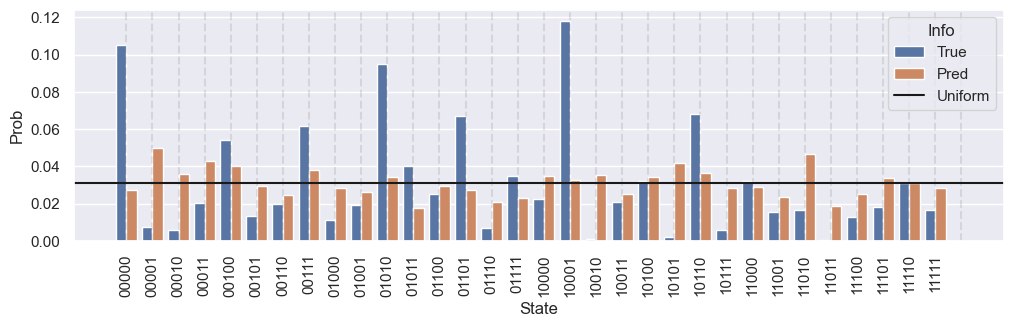

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

df = pd.DataFrame({
    'Info': ['True'] * 32 + ['Pred'] * 32,
    'State': [format(i, f'0{n}b') for i in range(32)] * 2,
    'Prob': list(Y_true[1].detach().cpu().numpy()) + list(Y_pred[1].detach().cpu().numpy())
})

sns.barplot(data=df, x='State', y='Prob', hue='Info', ax=ax)
ax.axhline(1/32, color='k', label='Uniform')
ax.legend(title='Info')
plt.xticks(rotation=90)

# Dividing lines for clarity.
for i in range(33):
    ax.axvline(i, color='k', linestyle='--', alpha=.1)

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.539, val loss - 0.445
Epoch 020: train loss - 0.505, val loss - 0.440
Epoch 030: train loss - 0.482, val loss - 0.439
Epoch 040: train loss - 0.469, val loss - 0.436
Epoch 050: train loss - 0.454, val loss - 0.434
Epoch 060: train loss - 0.453, val loss - 0.434
Epoch 070: train loss - 0.436, val loss - 0.435
Epoch 080: train loss - 0.431, val loss - 0.434
Epoch 090: train loss - 0.428, val loss - 0.433
Epoch 100: train loss - 0.422, val loss - 0.433
Epoch 110: train loss - 0.415, val loss - 0.434
Epoch 120: train loss - 0.408, val loss - 0.434
Epoch 130: train loss - 0.405, val loss - 0.433
Epoch 140: train loss - 0.402, val loss - 0.433
Epoch 150: train loss - 0.397, val loss - 0.434
Epoch 160: train loss - 0.391, val loss - 0.435
Epoch 170: train loss - 0.392, val loss - 0.435
Epoch 180: train loss - 0.386, val loss - 0.434
Epoch 190: train loss - 0.384, val loss - 0.436
Epoch 200: train loss - 0.386, val loss - 0.436
Epoch 210: train loss - 0.377, val loss 

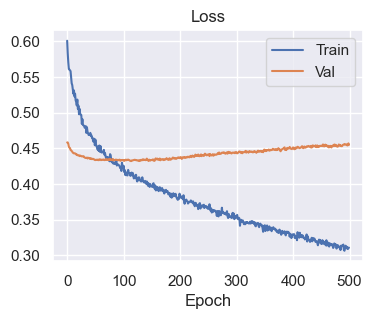

In [18]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    data_df=subset_same[subset_same['d'] == 0],
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['y' + format(i, f'0{n}b') for i in range(2 ** n)],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 512
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, 2 ** n),
)
model.to(device)

train_losses, val_losses = train_reg(
    model, device, KLDivLoss(reduction='batchmean'), train_loader, val_loader, 
    n_epochs=500, lr=1e-4, weight_decay=1e-4, verbose=True
)

# Set up a figure and axes.
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax, label='Train')
sns.lineplot(x=epochs, y=val_losses, ax=ax, label='Val')

# Beautification.
ax.set_title('Loss')
ax.set_xlabel('Epoch')

plt.show()

In [19]:
for X, Y_true in train_loader:
    X = X.to(device)
    Y_true = Y_true.to(device)
    Y_pred = Softmax()(model(Y_true))
    
    print('X')
    print(X.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_pred')
    print(Y_pred.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_true')
    print(Y_true.detach().cpu().numpy()[0][:5], '...')
    print()
    print('|Y_pred - Y_true|')
    print(abs((Y_pred - Y_true).detach().cpu().numpy())[0][:5], '...')
    
    break

X
[0.03710938 0.01953125 0.046875   0.04492188 0.05078125] ...

Y_pred
[0.03404807 0.02061715 0.02321097 0.01246154 0.02157153] ...

Y_true
[0.00929258 0.12041216 0.02035143 0.01411181 0.01470016] ...

|Y_pred - Y_true|
[0.02475549 0.09979501 0.00285954 0.00165026 0.00687137] ...


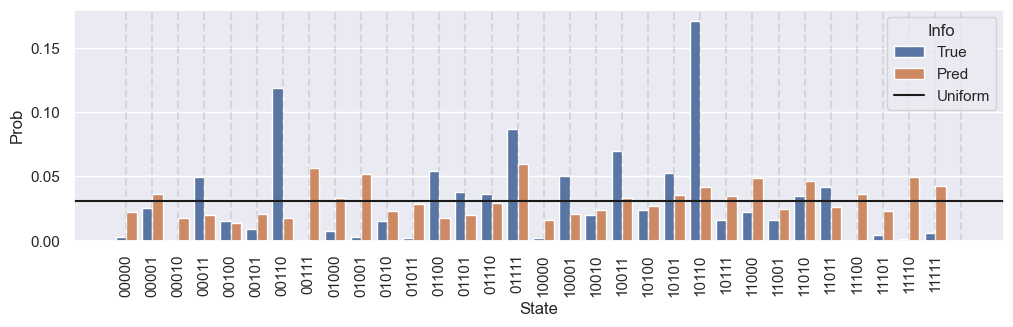

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

df = pd.DataFrame({
    'Info': ['True'] * 32 + ['Pred'] * 32,
    'State': [format(i, f'0{n}b') for i in range(32)] * 2,
    'Prob': list(Y_true[1].detach().cpu().numpy()) + list(Y_pred[1].detach().cpu().numpy())
})

sns.barplot(data=df, x='State', y='Prob', hue='Info', ax=ax)
ax.axhline(1/32, color='k', label='Uniform')
ax.legend(title='Info')
plt.xticks(rotation=90)

# Dividing lines for clarity.
for i in range(33):
    ax.axvline(i, color='k', linestyle='--', alpha=.1)

In [170]:
for X, Y_true in val_loader:
    X = X.to(device)
    Y_true = Y_true.to(device)
    Y_pred = Softmax()(model(Y_true))
    
    print('X')
    print(X.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_pred')
    print(Y_pred.detach().cpu().numpy()[0][:5], '...')
    print()
    print('Y_true')
    print(Y_true.detach().cpu().numpy()[0][:5], '...')
    print()
    print('|Y_pred - Y_true|')
    print(abs((Y_pred - Y_true).detach().cpu().numpy())[0][:5], '...')
    
    break

X
[0.02148438 0.03320312 0.0234375  0.01953125 0.0234375 ] ...

Y_pred
[0.03152806 0.02022175 0.0267515  0.01670619 0.04339503] ...

Y_true
[0.01464844 0.01513672 0.01464844 0.06738281 0.06640625] ...

|Y_pred - Y_true|
[0.01687962 0.00508503 0.01210306 0.05067663 0.02301122] ...


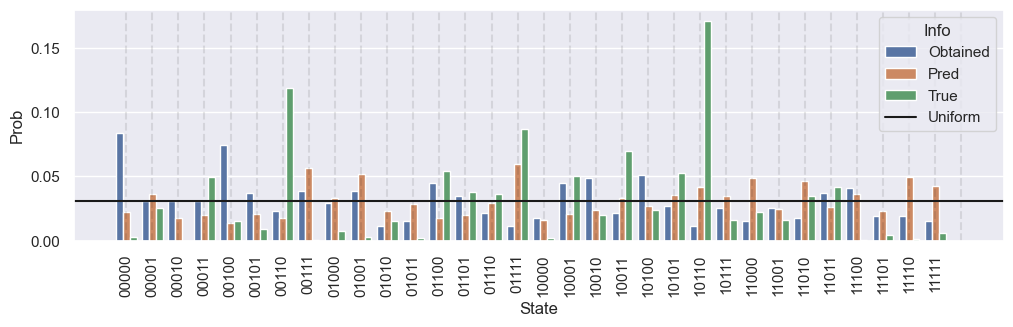

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

df = pd.DataFrame({
    'Info': ['Obtained'] * 32 + ['Pred'] * 32 + ['True'] * 32,
    'State': [format(i, f'0{n}b') for i in range(32)] * 3,
    'Prob': list(X[1].detach().cpu().numpy()) + list(Y_pred[1].detach().cpu().numpy()) + list(Y_true[1].detach().cpu().numpy())
})

sns.barplot(data=df, x='State', y='Prob', hue='Info', ax=ax)
ax.axhline(1/32, color='k', label='Uniform')
ax.legend(title='Info', loc='upper right')
plt.xticks(rotation=90)

# Dividing lines for clarity.
for i in range(33):
    ax.axvline(i, color='k', linestyle='--', alpha=.1)

### Narrowing in for just one device

Top-level training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 010: train loss - 0.478, val loss - 0.473
Epoch 020: train loss - 0.463, val loss - 0.460
Epoch 030: train loss - 0.453, val loss - 0.454
Epoch 040: train loss - 0.446, val loss - 0.446
Epoch 050: train loss - 0.440, val loss - 0.446
Epoch 060: train loss - 0.435, val loss - 0.442
Epoch 070: train loss - 0.432, val loss - 0.440
Epoch 080: train loss - 0.428, val loss - 0.437
Epoch 090: train loss - 0.426, val loss - 0.434
Epoch 100: train loss - 0.423, val loss - 0.433
Epoch 110: train loss - 0.421, val loss - 0.431
Epoch 120: train loss - 0.418, val loss - 0.433
Epoch 130: train loss - 0.418, val loss - 0.430
Epoch 140: train loss - 0.415, val loss - 0.429
Epoch 150: train loss - 0.412, val loss - 0.429
Epoch 160: train loss - 0.410, val loss - 0.428
Epoch 170: train loss - 0.410, val loss - 0.428
Epoch 180: train loss - 0.409, val loss - 0.426
Epoch 190: train loss - 0.408, val loss - 0.426
Epoch 200: train loss - 0.405, val loss - 0.426


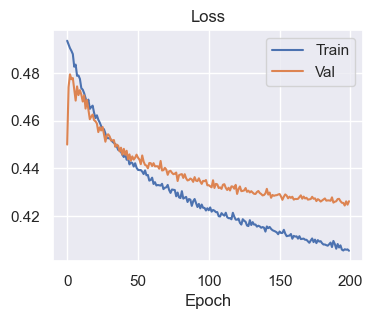

In [22]:
# Build loaders.
train_loader, val_loader, test_loader = build_loaders(
    data_df=subset_same[subset_same['device'] == 0],
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['y' + format(i, f'0{n}b') for i in range(2 ** n)],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 64
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(),
    Linear(hidden_size, 2 ** n),
)
model.to(device)

train_losses, val_losses = train_reg(
    model, device, KLDivLoss(reduction='batchmean'), train_loader, val_loader, 
    n_epochs=200, lr=1e-5, weight_decay=1e-4, verbose=True
)

# Set up a figure and axes.
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax, label='Train')
sns.lineplot(x=epochs, y=val_losses, ax=ax, label='Val')

# Beautification.
ax.set_title('Loss')
ax.set_xlabel('Epoch')

plt.show()

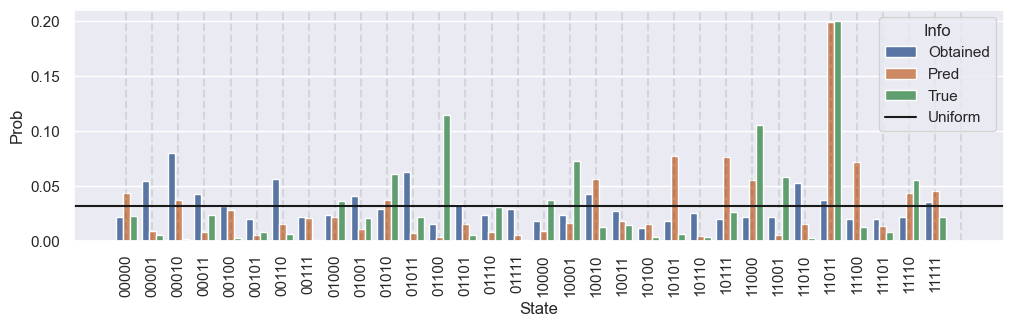

In [23]:
for X, Y_true in train_loader:
    X = X.to(device)
    Y_true = Y_true.to(device)
    Y_pred = Softmax()(model(Y_true))
    break
    
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

df = pd.DataFrame({
    'Info': ['Obtained'] * 32 + ['Pred'] * 32 + ['True'] * 32,
    'State': [format(i, f'0{n}b') for i in range(32)] * 3,
    'Prob': list(X[1].detach().cpu().numpy()) + list(Y_pred[1].detach().cpu().numpy()) + list(Y_true[1].detach().cpu().numpy())
})

sns.barplot(data=df, x='State', y='Prob', hue='Info', ax=ax)
ax.axhline(1/32, color='k', label='Uniform')
ax.legend(title='Info', loc='upper right')
plt.xticks(rotation=90)

# Dividing lines for clarity.
for i in range(33):
    ax.axvline(i, color='k', linestyle='--', alpha=.1)

## Superconducting vs Ion Trap

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.663, val loss - 0.646, train acc - 0.481, val acc - 0.679
Epoch 020: train loss - 0.600, val loss - 0.597, train acc - 0.626, val acc - 0.833
Epoch 030: train loss - 0.561, val loss - 0.556, train acc - 0.712, val acc - 0.881
Epoch 040: train loss - 0.513, val loss - 0.515, train acc - 0.733, val acc - 0.905
Epoch 050: train loss - 0.466, val loss - 0.477, train acc - 0.819, val acc - 0.905
Epoch 060: train loss - 0.437, val loss - 0.443, train acc - 0.830, val acc - 0.905
Epoch 070: train loss - 0.401, val loss - 0.415, train acc - 0.853, val acc - 0.929
Epoch 080: train loss - 0.382, val loss - 0.385, train acc - 0.876, val acc - 0.952
Epoch 090: train loss - 0.356, val loss - 0.359, train acc - 0.880, val acc - 0.952
Epoch 100: train loss - 0.332, val loss - 0.337, train acc - 0.874, val acc - 0.952
Epoch 110: train loss - 0.302, val loss - 0.312, train acc - 0.895, val acc - 0.952
Epoch 120: train loss - 0.295, val loss - 0.290, train acc - 0.878, val acc 

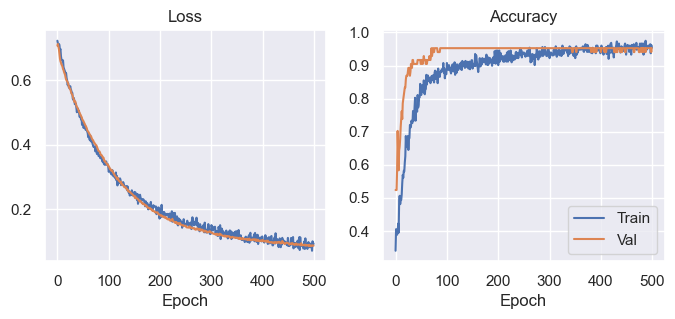

In [43]:
# Loaders.
train_loader_5, val_loader_5, test_loader_5 = build_loaders(
    # Differing-type, depth-5
    data_df=stratified_sample(subset_diff[subset_diff['d'] == 0], n=350*2),
    # Raw.
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader_5, val_loader_5,
                                                       n_epochs=500, lr=3e-5, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [45]:
evaluate(model, device, test_loader_5, BCEWithLogitsLoss())

(0.09563533810919138, 0.95)

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.710, val loss - 0.684, train acc - 0.380, val acc - 0.452
Epoch 020: train loss - 0.663, val loss - 0.661, train acc - 0.468, val acc - 0.560
Epoch 030: train loss - 0.640, val loss - 0.638, train acc - 0.506, val acc - 0.607
Epoch 040: train loss - 0.611, val loss - 0.621, train acc - 0.540, val acc - 0.619
Epoch 050: train loss - 0.573, val loss - 0.604, train acc - 0.605, val acc - 0.607
Epoch 060: train loss - 0.566, val loss - 0.591, train acc - 0.569, val acc - 0.583
Epoch 070: train loss - 0.542, val loss - 0.579, train acc - 0.599, val acc - 0.607
Epoch 080: train loss - 0.532, val loss - 0.564, train acc - 0.603, val acc - 0.595
Epoch 090: train loss - 0.518, val loss - 0.556, train acc - 0.603, val acc - 0.595
Epoch 100: train loss - 0.501, val loss - 0.547, train acc - 0.632, val acc - 0.583
Epoch 110: train loss - 0.496, val loss - 0.537, train acc - 0.647, val acc - 0.571
Epoch 120: train loss - 0.482, val loss - 0.530, train acc - 0.658, val acc 

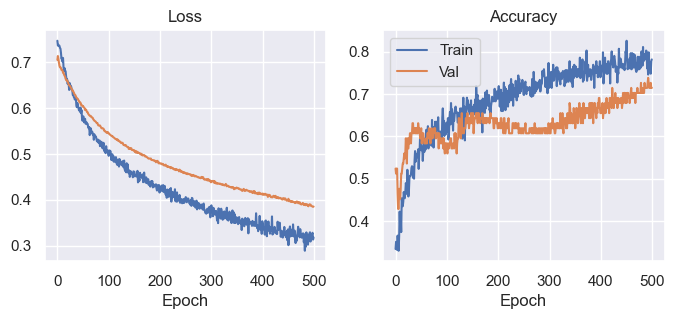

In [40]:
# Loaders.
train_loader_5, val_loader_5, test_loader_5 = build_loaders(
    # Differing-type, depth-5
    data_df=stratified_sample(subset_diff[subset_diff['d'] == 0], n=350*2),
    # Discrepancy.
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader_5, val_loader_5,
                                                       n_epochs=500, lr=3e-5, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [42]:
evaluate(model, device, test_loader_5, BCEWithLogitsLoss())

(0.39597658519891815, 0.6928571428571428)

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.715, val loss - 0.682, train acc - 0.387, val acc - 0.464
Epoch 020: train loss - 0.673, val loss - 0.651, train acc - 0.435, val acc - 0.524
Epoch 030: train loss - 0.640, val loss - 0.626, train acc - 0.485, val acc - 0.619
Epoch 040: train loss - 0.615, val loss - 0.603, train acc - 0.502, val acc - 0.655
Epoch 050: train loss - 0.581, val loss - 0.582, train acc - 0.578, val acc - 0.655
Epoch 060: train loss - 0.576, val loss - 0.566, train acc - 0.517, val acc - 0.690
Epoch 070: train loss - 0.544, val loss - 0.552, train acc - 0.622, val acc - 0.726
Epoch 080: train loss - 0.532, val loss - 0.538, train acc - 0.592, val acc - 0.726
Epoch 090: train loss - 0.522, val loss - 0.523, train acc - 0.592, val acc - 0.726
Epoch 100: train loss - 0.502, val loss - 0.511, train acc - 0.605, val acc - 0.714
Epoch 110: train loss - 0.487, val loss - 0.500, train acc - 0.651, val acc - 0.726
Epoch 120: train loss - 0.481, val loss - 0.490, train acc - 0.637, val acc 

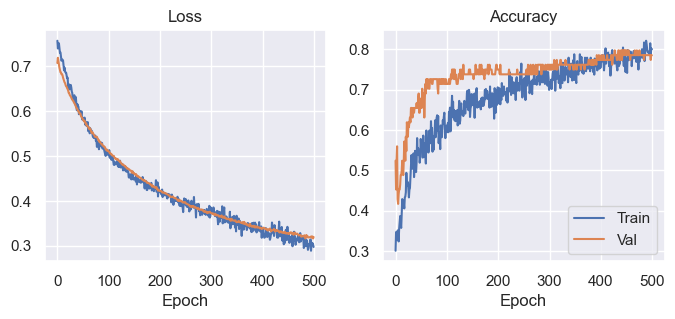

In [36]:
# Loaders.
train_loader_10, val_loader_10, test_loader_10 = build_loaders(
    # Differing-type, depth-10
    data_df=stratified_sample(subset_diff[subset_diff['d'] == 1], n=350*2),
    # Raw.
    feature_cols=[format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader_10, val_loader_10,
                                                       n_epochs=500, lr=3e-5, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [37]:
evaluate(model, device, test_loader_10, BCEWithLogitsLoss())

(0.4114962844488521, 0.6714285714285714)

Top-level training:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 010: train loss - 0.651, val loss - 0.639, train acc - 0.504, val acc - 0.655
Epoch 020: train loss - 0.574, val loss - 0.578, train acc - 0.695, val acc - 0.893
Epoch 030: train loss - 0.528, val loss - 0.527, train acc - 0.796, val acc - 0.940
Epoch 040: train loss - 0.476, val loss - 0.479, train acc - 0.821, val acc - 0.964
Epoch 050: train loss - 0.423, val loss - 0.434, train acc - 0.901, val acc - 0.964
Epoch 060: train loss - 0.396, val loss - 0.394, train acc - 0.887, val acc - 0.976
Epoch 070: train loss - 0.346, val loss - 0.359, train acc - 0.924, val acc - 0.988
Epoch 080: train loss - 0.322, val loss - 0.326, train acc - 0.924, val acc - 0.988
Epoch 090: train loss - 0.290, val loss - 0.291, train acc - 0.939, val acc - 0.988
Epoch 100: train loss - 0.262, val loss - 0.264, train acc - 0.947, val acc - 0.988
Epoch 110: train loss - 0.239, val loss - 0.242, train acc - 0.960, val acc - 0.988
Epoch 120: train loss - 0.216, val loss - 0.219, train acc - 0.960, val acc 

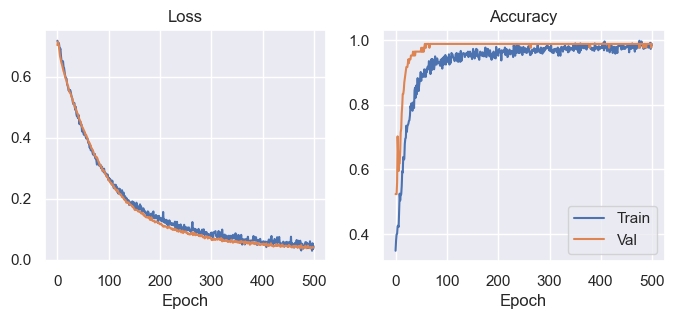

In [38]:
# Loaders.
train_loader_10, val_loader_10, test_loader_10 = build_loaders(
    # Differing-type, depth-10
    data_df=stratified_sample(subset_diff[subset_diff['d'] == 1], n=350*2),
    # Discrepancy.
    feature_cols=['x' + format(i, f'0{n}b') for i in range(2 ** n)],
    label_cols=['device'],
    split=[.2, .15],
    batch_size=32
)

# Model.
hidden_size = 128
model = Sequential(
    Linear(2 ** n, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), ReLU(), Dropout(.5),
    Linear(hidden_size, data_df['device'].nunique())
)
model.to(device)

train_losses, train_accs, val_losses, val_accs = train(model, device, BCEWithLogitsLoss(), train_loader_10, val_loader_10,
                                                       n_epochs=500, lr=3e-5, weight_decay=1e-4, verbose=True)

# Set up a figure and axes.
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(8, 3))

# Plot the stats.
epochs = np.arange(len(train_losses))
sns.lineplot(x=epochs, y=train_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=val_losses, ax=ax_loss)
sns.lineplot(x=epochs, y=train_accs, ax=ax_acc, label='Train')
sns.lineplot(x=epochs, y=val_accs, ax=ax_acc, label='Val')

# Beautification.
ax_loss.set_title('Loss')
ax_loss.set_xlabel('Epoch')

ax_acc.set_title('Accuracy')
ax_acc.set_xlabel('Epoch')

plt.show()

In [39]:
evaluate(model, device, test_loader_10, BCEWithLogitsLoss())

(0.022173754697797043, 1.0)